# Data Analysis Report Part A

In [55]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler , normalize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
import statsmodels.tsa.statespace.tools
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_white
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import boxcox
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error
)

## 1)  Clustering
Download dataset sku_data.csv. The dataset is sampled from a dataset in the UCI data repository, which implies that the dataset is a subset of the original dataset. You may find the description of the original dataset on https://archive.ics.uci.edu/dataset/585/stock+keeping+units (accessed on 06/Feb/2026). Cluster the dataset and explain your clustering process.

In [182]:
sku_data = pd.read_csv("Datasets/sku_data.csv")

In [183]:
sku_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2279 entries, 0 to 2278
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2279 non-null   int64  
 1   Unitprice        2279 non-null   float64
 2   Expire date      2279 non-null   int64  
 3   Outbound number  2279 non-null   int64  
 4   Total outbound   2279 non-null   float64
 5   Pal grossweight  2279 non-null   float64
 6   Pal height       2279 non-null   float64
 7   Units per pal    2279 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 142.6 KB


In [184]:
sku_data

,ID,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,1,0.058,547,9,2441.0,105.60,1.56,1920
1,2,0.954,547,0,0.0,207.68,1.00,384
2,3,2.385,547,12,23.0,165.78,1.02,108
3,4,5.100,547,0,0.0,221.04,1.05,72
4,5,0.000,547,0,0.0,0.00,0.00,0
...,...,...,...,...,...,...,...,...
2274,2275,0.000,0,0,0.0,2.70,0.00,10
2275,2276,0.000,0,1,1.0,9.58,0.00,1
2276,2277,0.000,0,0,0.0,38.36,0.00,4
2277,2278,0.000,0,1,1.0,25.11,0.00,3


In [185]:
# Separate ID
X = sku_data.drop(columns=["ID"])

# Scale only feature columns
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(X)

# Convert back to DataFrame with original column names
Y = pd.DataFrame(Y_scaled, columns=X.columns, index=X.index)

In [186]:
Y

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,-0.291531,0.567340,-0.324216,0.796668,-0.530679,1.607262,0.185507
1,-0.229506,0.567340,-0.337072,-0.341031,0.089563,0.592762,-0.059194
2,-0.130446,0.567340,-0.319931,-0.330311,-0.165023,0.628994,-0.103163
3,0.057497,0.567340,-0.337072,-0.341031,0.170739,0.683342,-0.108899
4,-0.295546,0.567340,-0.337072,-0.341031,-1.172310,-1.218845,-0.120369
...,...,...,...,...,...,...,...
2274,-0.295546,-1.704042,-0.337072,-0.341031,-1.155905,-1.218845,-0.118776
2275,-0.295546,-1.704042,-0.335643,-0.340564,-1.114101,-1.218845,-0.120210
2276,-0.295546,-1.704042,-0.337072,-0.341031,-0.939233,-1.218845,-0.119732
2277,-0.295546,-1.704042,-0.335643,-0.340564,-1.019740,-1.218845,-0.119891


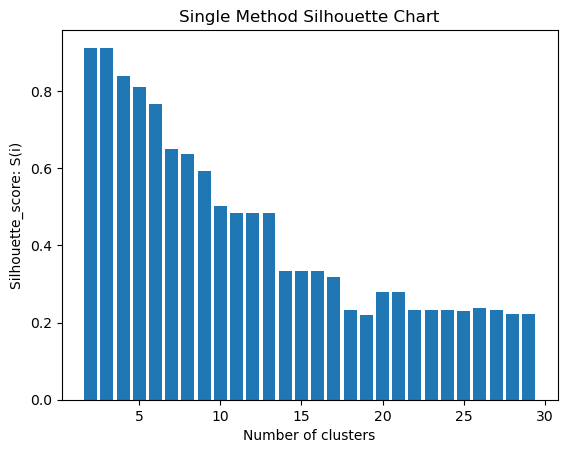

In [187]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

y=[]
silhouette_scores = []

for k in range(2,30):
    Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='single', compute_distances=True)
    # Appending the silhouette scores of the different models to the list
    silhouette_scores.append(silhouette_score(Y, Hclustering.fit_predict(Y)))
    # Plotting a bar graph to compare the results

k=range(2,30)
plt.bar(k, silhouette_scores)
plt.title("Single Method Silhouette Chart")
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_score: S(i)')
plt.show()

# max(silhouette_scores)

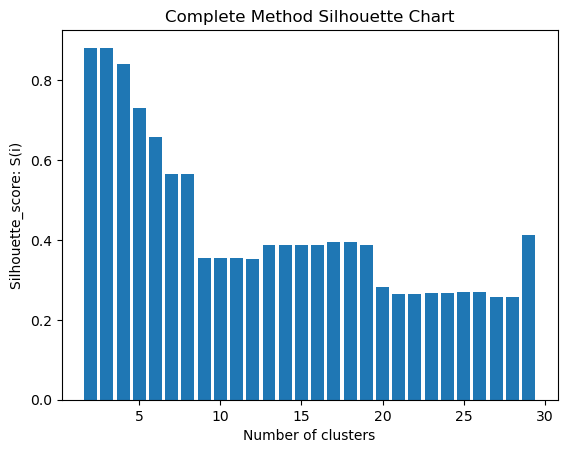

0.8815350683311919

In [188]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

y=[]
silhouette_scores = []

for k in range(2,30):
    Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='complete', compute_distances=True)
    silhouette_scores.append(silhouette_score(Y, Hclustering.fit_predict(Y)))
    # Plotting a bar graph to compare the results

k=range(2,30)
plt.bar(k, silhouette_scores)
plt.title("Complete Method Silhouette Chart")
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_score: S(i)')
plt.show()

max(silhouette_scores)

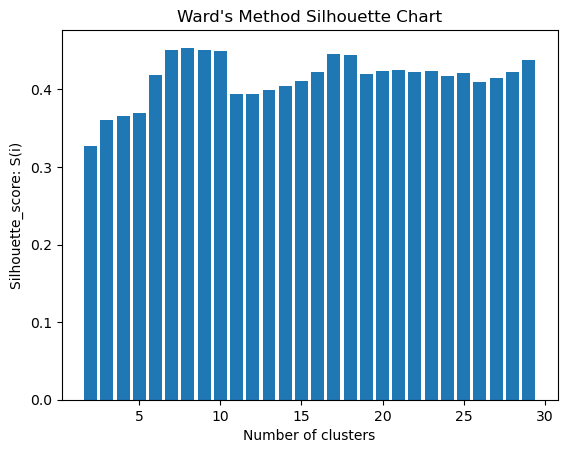

In [189]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

y=[]
silhouette_scores = []

for k in range(2,30):
    Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward', compute_distances=True)
    silhouette_scores.append(silhouette_score(Y, Hclustering.fit_predict(Y)))
    # Plotting a bar graph to compare the results

k=range(2,30)
plt.bar(k, silhouette_scores)
plt.title("Ward's Method Silhouette Chart")
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_score: S(i)')
plt.show()

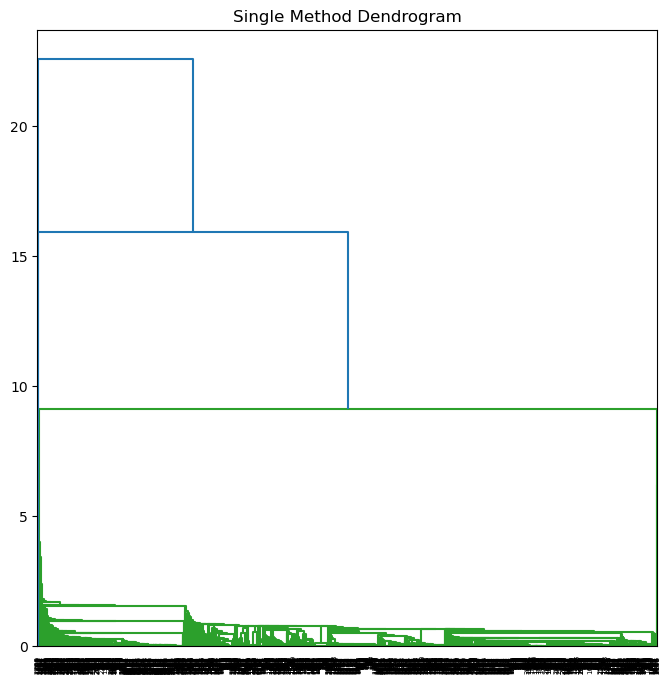

In [190]:
# Plot dendrogram
Z1 = shc.linkage(Y, method="single")
plt.figure(figsize =(8, 8))
plt.title('Single Method Dendrogram')
Dendrogram = shc.dendrogram(Z1)

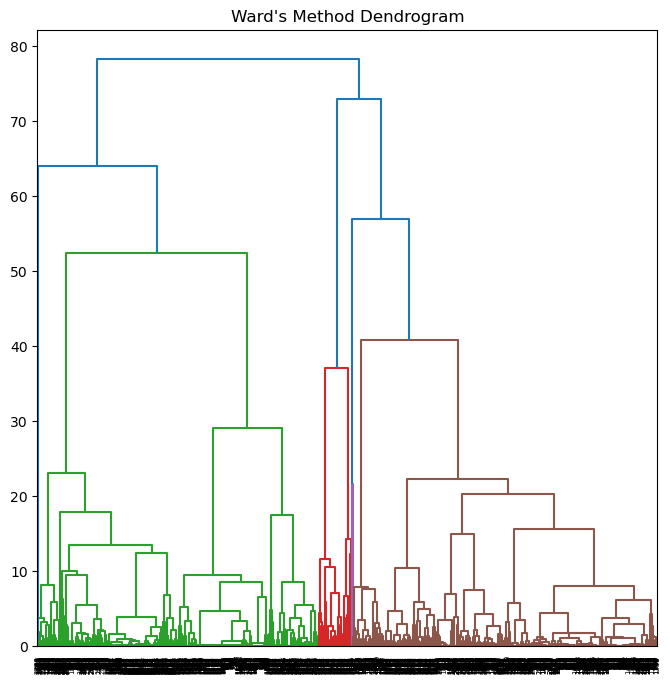

In [191]:
# Plot dendrogram
Z = shc.linkage(Y, method="ward")
plt.figure(figsize =(8, 8))
plt.title("Ward's Method Dendrogram")
Dendrogram = shc.dendrogram(Z)

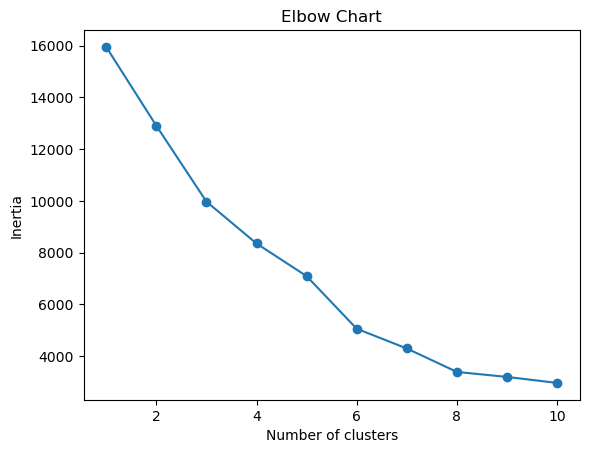

In [195]:
inertias = []						#prepare to store the inertia for each cluster count to inertias
for i in range(1,11):					#to create a for loop
    kmeans = KMeans(n_clusters=i,  random_state=42)			#to use the k-means and set the number of clusters to be i
    kmeans.fit(Y)				#to cluster the given dataset dfMPG
    inertias.append(kmeans.inertia_)

#inertia = kmeans.inertia_  #Inertia is a measure of how well a dataset is clustered using the K-means algorithm

plt.plot(range(1,11), inertias, marker='o')		#to plot a scree plot for you to determine the number of clusters
plt.title('Elbow Chart')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [193]:
k = 6  # example chosen from dendrogram/silhouette
labels_init = fcluster(Z, t=k, criterion="maxclust")

In [207]:
Hclustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward', compute_distances=True)
silhouette_score(Y, Hclustering.fit_predict(Y))

0.4190424422311754

In [196]:
# Get the starting position of the centroids
centroids_init = np.vstack([
    Y_scaled[labels_init == c].mean(axis=0)
    for c in range(1, k+1)
])

In [204]:
centers_data = pd.DataFrame()

centers_data["Feature"]  = Y.columns
centers_data["Centre_1"] = centroids_init[0]
centers_data["Centre_2"] = centroids_init[1]
centers_data["Centre_3"] = centroids_init[2]
centers_data["Centre_4"] = centroids_init[3]
centers_data["Centre_5"] = centroids_init[4]
centers_data["Centre_6"] = centroids_init[5]

centers_data

,feature,Centre_1,Centre_2,Centre_3,Centre_4,Centre_5,Centre_6
0,Unitprice,-0.295071,-0.187222,-0.154265,-0.132788,23.200901,0.110155
1,Expire date,-1.704042,-1.704042,0.492951,0.660247,-1.704042,0.493505
2,Outbound number,-0.269936,-0.322259,-0.315973,3.427647,-0.336120,-0.081286
3,Total outbound,0.123883,-0.255594,-0.257981,3.263923,-0.340564,-0.121377
4,Pal grossweight,3.688528,-0.665701,-0.360812,0.185416,-0.390525,0.446704
5,Pal height,-1.218845,-0.576532,-1.200711,0.550196,-0.741788,0.761469
6,Units per pal,31.741680,0.090997,-0.053093,-0.069967,-0.119891,-0.066187


In [208]:
# Iterate the kmeans algorithm 
kmeans = KMeans(n_clusters=6, init = centroids_init, max_iter=300,  random_state=42)
kmeans.fit(Y)

labels = kmeans.labels_
centers = kmeans.cluster_centers_   #luster centres
print("The cluster centres are:",centers)

centers_data = pd.DataFrame()

centers_data["Feature"]  = Y.columns
centers_data["Centre_1"] = centers[0]
centers_data["Centre_2"] = centers[1]
centers_data["Centre_3"] = centers[2]
centers_data["Centre_4"] = centers[3]
centers_data["Centre_5"] = centers[4]
centers_data["Centre_6"] = centers[5]

centers_data

The cluster centres are: [[-0.29507146 -1.70404153 -0.26993644  0.12388331  3.68852754 -1.21884495
  31.74167951]
 [-0.18545891 -1.70404153 -0.3222164  -0.24917787 -0.7065212  -0.63407261
   0.09052717]
 [-0.16412485  0.52096    -0.31634515 -0.25505048 -0.58650541 -1.19406636
  -0.05259367]
 [-0.12909382  0.70297279  3.80269878  3.66966106  0.22560147  0.55330115
  -0.06961369]
 [23.20090068 -1.70404153 -0.33611963 -0.34056442 -0.39052525 -0.74178848
  -0.11989106]
 [ 0.09891815  0.46107794 -0.0563294  -0.1018434   0.51661368  0.71529935
  -0.06448783]]


,Feature,Centre_1,Centre_2,Centre_3,Centre_4,Centre_5,Centre_6
0,Unitprice,-0.295071,-0.185459,-0.164125,-0.129094,23.200901,0.098918
1,Expire date,-1.704042,-1.704042,0.520960,0.702973,-1.704042,0.461078
2,Outbound number,-0.269936,-0.322216,-0.316345,3.802699,-0.336120,-0.056329
3,Total outbound,0.123883,-0.249178,-0.255050,3.669661,-0.340564,-0.101843
4,Pal grossweight,3.688528,-0.706521,-0.586505,0.225601,-0.390525,0.516614
5,Pal height,-1.218845,-0.634073,-1.194066,0.553301,-0.741788,0.715299
6,Units per pal,31.741680,0.090527,-0.052594,-0.069614,-0.119891,-0.064488


In [209]:
# Observe silhouette score
silhouette_score(Y, kmeans.predict(Y))

0.4118108801455129

## 2) Time series
A manufacturer, CX, started its business about many years ago. Recently, one of its products, compact crane, has become the leading product of CX, but the sales team has suffered with repeated over productions and under productions, due to wrong sales forecast. The production team needs to schedule how many compact excavators need to be produced one month in advance. Download dataset TimeSeries.xlsx for the sales data. Develop a time series forecasting model for CX and provide your modelling process.

In [100]:
TimeSeries = pd.read_csv("Datasets/TimeSeries.csv")

In [101]:
TimeSeries["Sales"] = (
    TimeSeries["Sales"]
        .str.strip()              # remove leading/trailing spaces
        .str.replace(",", "", regex=False)  # remove commas
)

TimeSeries["Sales"] = pd.to_numeric(TimeSeries["Sales"], errors="coerce")

In [102]:
# Need to fix that the year is only there for the january
TimeSeries["Year"] = TimeSeries["Year"].ffill()

In [103]:
# Create a date column as first of the month
TimeSeries["Year"] = TimeSeries["Year"].astype(int) 
TimeSeries["Date"] = pd.to_datetime(
    dict(year=TimeSeries["Year"], month=TimeSeries["Month"], day=1)
)
TimeSeries = TimeSeries.sort_values("Date").set_index("Date")

The test results are Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(9.392364663796116e-10), z=np.float64(6.119407988324747), Tau=np.float64(0.33367733058135535), s=np.float64(3880.0), var_s=np.float64(401810.0), slope=np.float64(55.063291139240505), intercept=np.float64(14770.189873417721))

The p-value of the Mann-Kendall trend test= 9.392364663796116e-10
Interpretation Guidelines:
if p < 0.05: reject the null hypothesis and conclude that a statistically significant trend exists
if p >= 0.05: fail to reject the null hypothesis and conclude that there is no evidence showing 'trend being present'

The p-value of the Kruskal-Wallis test= 2.632282354064886e-09
Interpretation Guidelines:
if p < 0.05: reject the null hypothesis and conclude that seasonality is present
if p >= 0.05: fail to reject the null hypothesis and conclude that there is no evidence showing 'seasonality being present'

The p-value of the Augmented Dickey-Fuller unit root test= 0.6359081904491785
Interpr

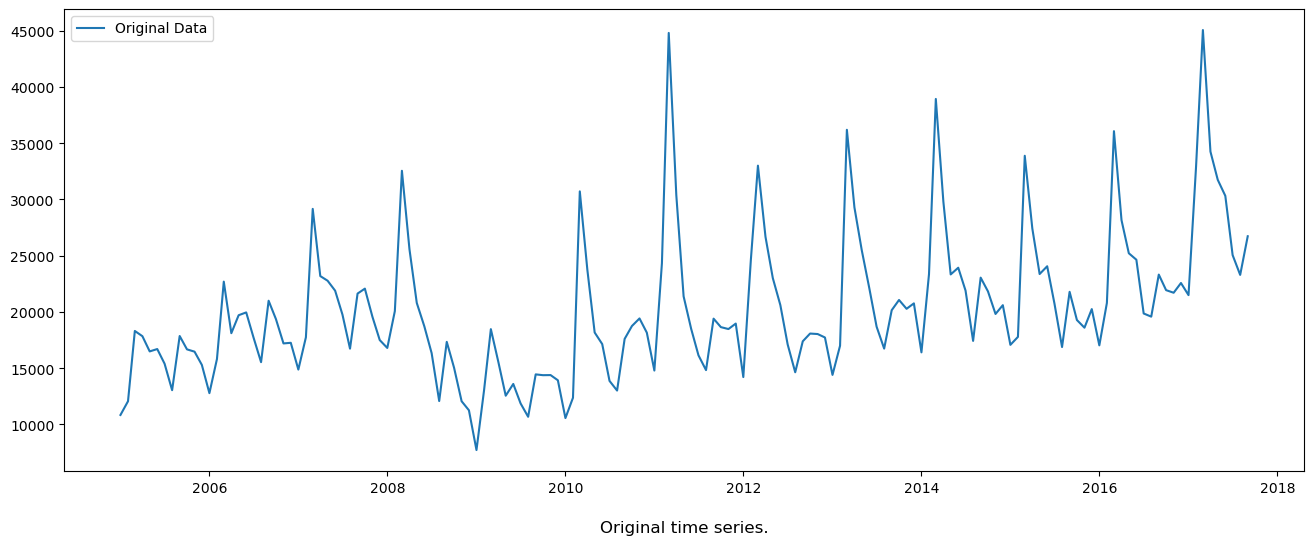

In [117]:
plt.figure(figsize=(16, 6))
plt.tight_layout()  # Use plt instead of fig
plt.subplots_adjust(wspace=1, hspace=0.5)  # Reduce hspace

plt.plot(TimeSeries['Sales'], label='Original Data')
plt.legend(loc='upper left')
plt.title("Original time series.",y=-0.15)


test1 = mk.original_test(TimeSeries['Sales'])
print("The test results are", test1)

print("\nThe p-value of the Mann-Kendall trend test=", test1.p)
print("Interpretation Guidelines:")
print("if p < 0.05: reject the null hypothesis and conclude that a statistically significant trend exists.")
print("if p >= 0.05: fail to reject the null hypothesis and conclude that there is no evidence showing 'trend being present'.")

series=TimeSeries.index.to_series() # to convert


H_statistic, kruskal_p_value = stats.kruskal(*[TimeSeries['Sales'][series.dt.month == time]
                                               for time in series.dt.month.unique()])
# print("", H_statistic, kruskal_p_value)

print("\nThe p-value of the Kruskal-Wallis test=", kruskal_p_value)
print("Interpretation Guidelines:")
print("if p < 0.05: reject the null hypothesis and conclude that seasonality is present.")
print("if p >= 0.05: fail to reject the null hypothesis and conclude that there is no evidence showing 'seasonality being present'.")

test_result = adfuller(TimeSeries['Sales'])

p_value_of_the_Adfuller_test = test_result[1]
print("\nThe p-value of the Augmented Dickey-Fuller unit root test=", p_value_of_the_Adfuller_test)
print("Interpretation Guidelines:")
print("if p < 0.05: reject the null hypothesis. We conclude that the series is stationary.")
print("if p >= 0.05: fail to reject the null hypothesis. We conclude that the series is non-stationary.")

In [217]:
TimeSeries_Data = seasonal_decompose(TimeSeries['Sales'], model='multiplicative') #assume the seasonal pattern is multiplicative
# Extract components
trend = TimeSeries_Data.trend
seasonal = TimeSeries_Data.seasonal
residual = TimeSeries_Data.resid

Text(0.5, 1.0, 'Trend Component')

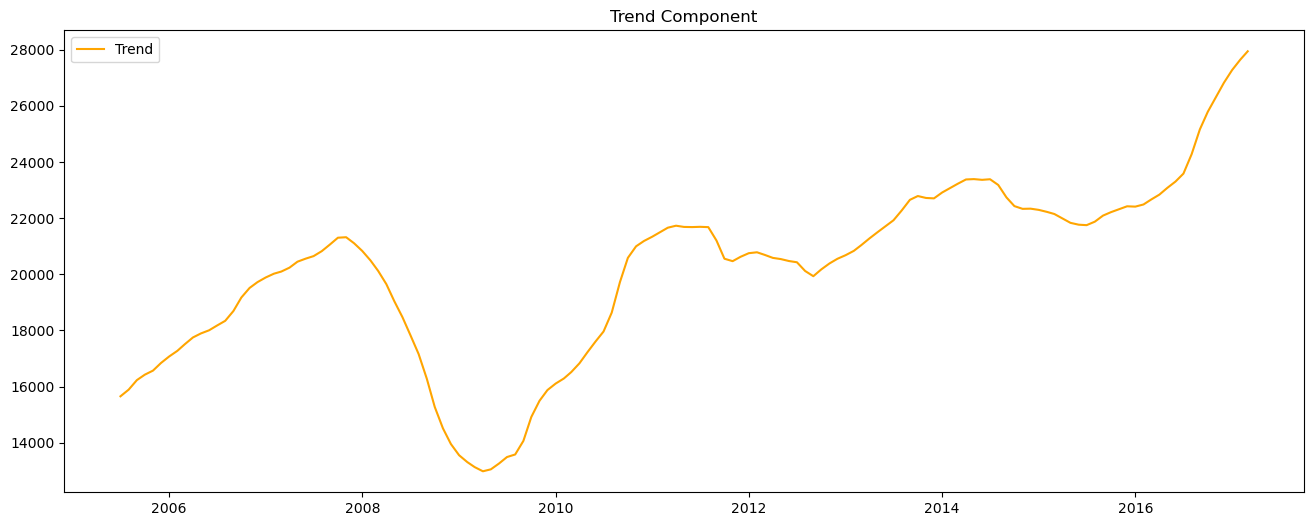

In [218]:
plt.figure(figsize=(16, 6))
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.title('Trend Component')

Text(0.5, 1.0, 'Seasonal Component')

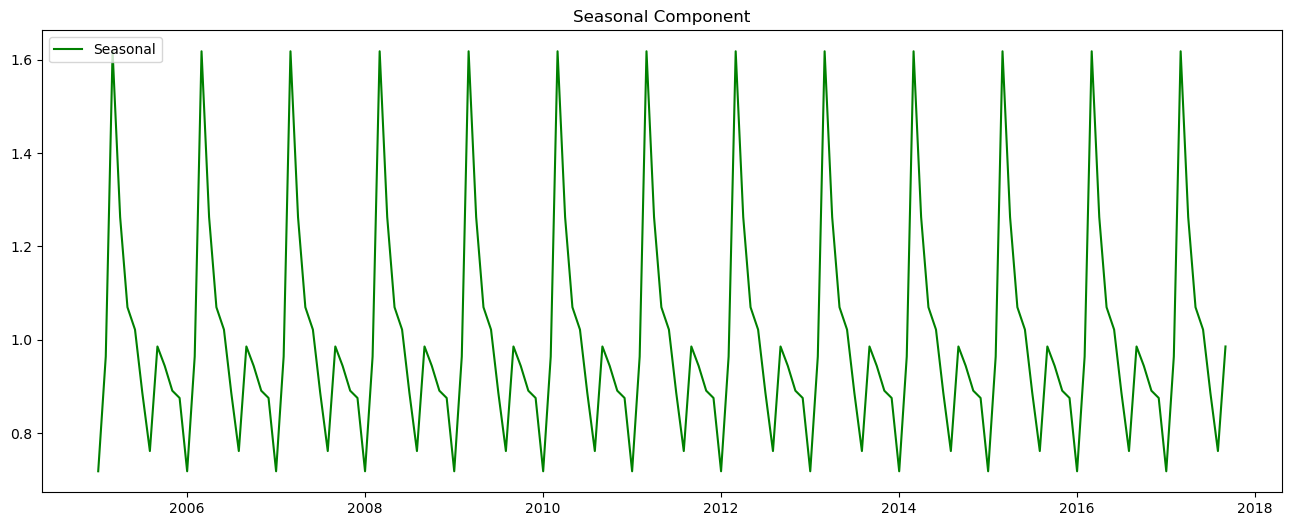

In [219]:
plt.figure(figsize=(16, 6))
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.title('Seasonal Component')

Text(0.5, 1.0, 'Multiplicative Residual Component')

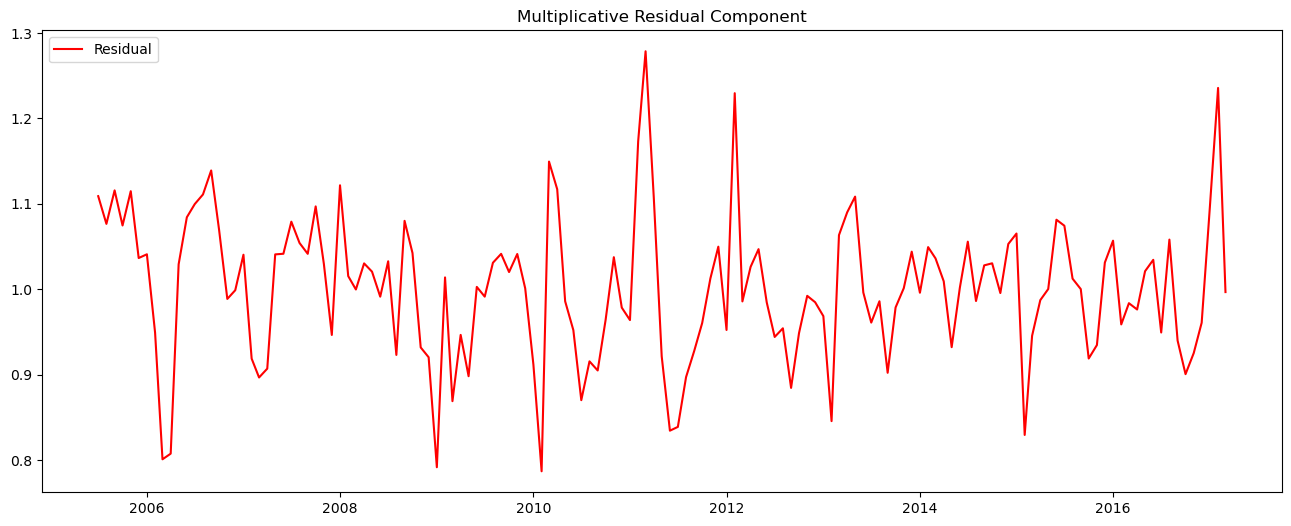

In [244]:
plt.figure(figsize=(16, 6))
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Multiplicative Residual Component')

Text(0.5, 1.0, 'Residual Component')

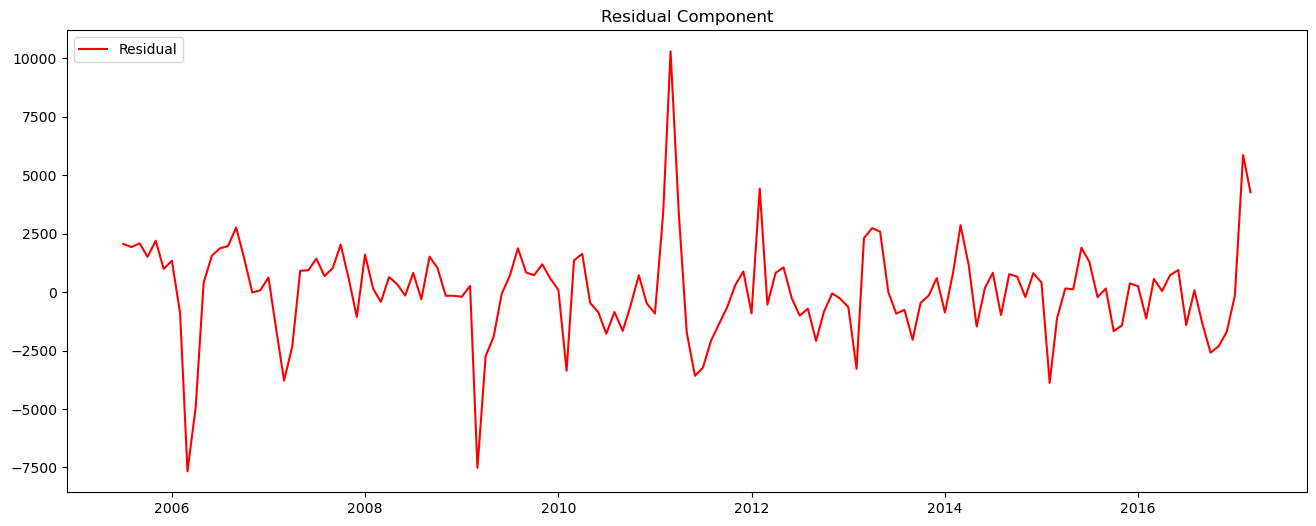

In [243]:
TimeSeries_Data = seasonal_decompose(TimeSeries['Sales'], model='additive') #assume the seasonal pattern is multiplicative
# Extract components
residual_add = TimeSeries_Data.resid
plt.figure(figsize=(16, 6))
plt.plot(residual_add, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Additive Residual Component')

In [235]:
# Split into train and test set
train_TimeSeries = TimeSeries[:-12]		
test_TimeSeries  = TimeSeries[-12:]

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


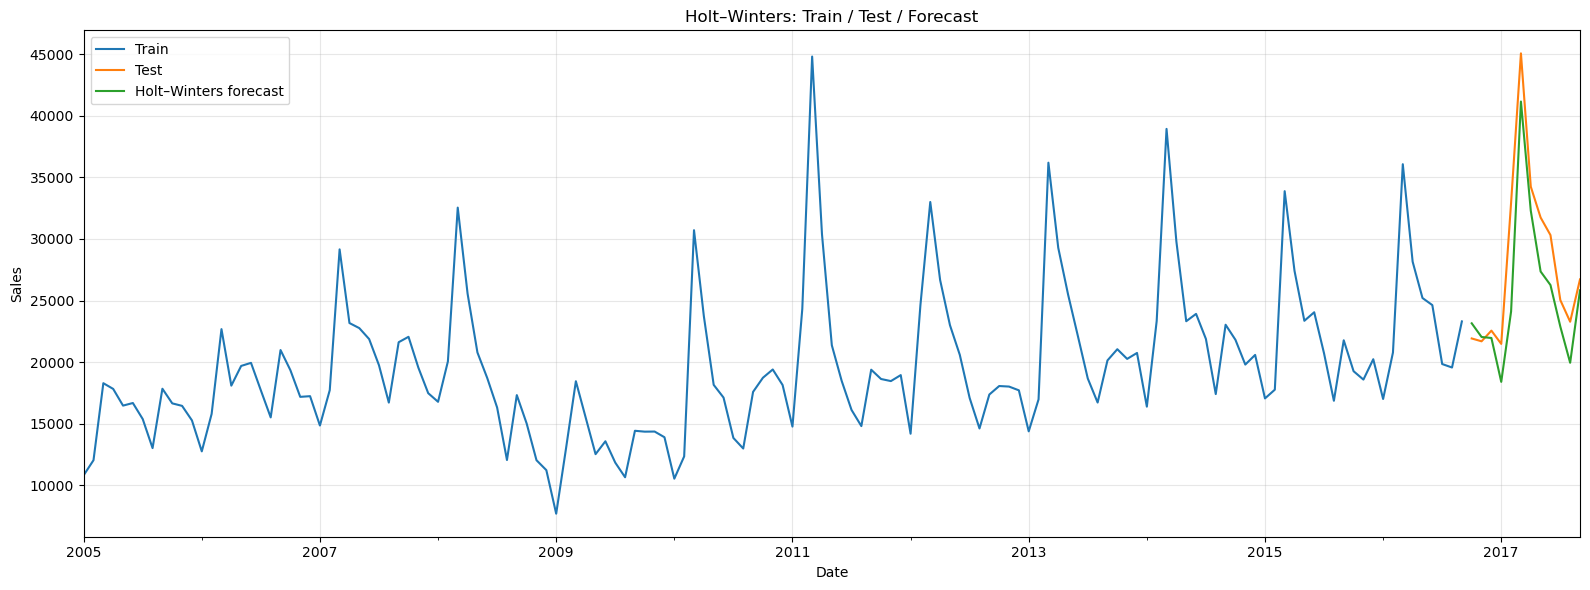

In [245]:
# Fit Holt-Winters on training data
HW_model = ExponentialSmoothing(
    train_TimeSeries["Sales"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

# Forecast exactly the length of the test set (safer than hard-coding 21)
n_forecast = len(test_TimeSeries)
hw_forecast = HW_model.forecast(steps=n_forecast)

# ---- Plot: train, test, forecast ----
fig, ax = plt.subplots(figsize=(16, 6))

train_TimeSeries["Sales"].plot(ax=ax, label="Train")
test_TimeSeries["Sales"].plot(ax=ax, label="Test")
hw_forecast.plot(ax=ax, label="Holt–Winters forecast")

ax.set_title("Holt–Winters: Train / Test / Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# # ---- Evaluation ----
# mae = mean_absolute_error(test_TimeSeries["Sales"], hw_forecast)
# print(f"Mean Absolute Error (Holt–Winters) = {mae:.2f}")
# print(f"Holt–Winters AIC = {HW_model.aic:.2f}")
# print(f"Holt–Winters BIC = {HW_model.bic:.2f}")

In [246]:
print(HW_model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    Sales   No. Observations:                  141
Model:             ExponentialSmoothing   SSE                      564165452.158
Optimized:                         True   AIC                           2175.496
Trend:                         Additive   BIC                           2222.676
Seasonal:                Multiplicative   AICC                          2181.102
Seasonal Periods:                    12   Date:                 Mon, 02 Mar 2026
Box-Cox:                          False   Time:                         16:36:23
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6520640                alpha                 True
smoothing_trend          

Text(0.5, -0.15, 'Figure 6.3: PACF.')

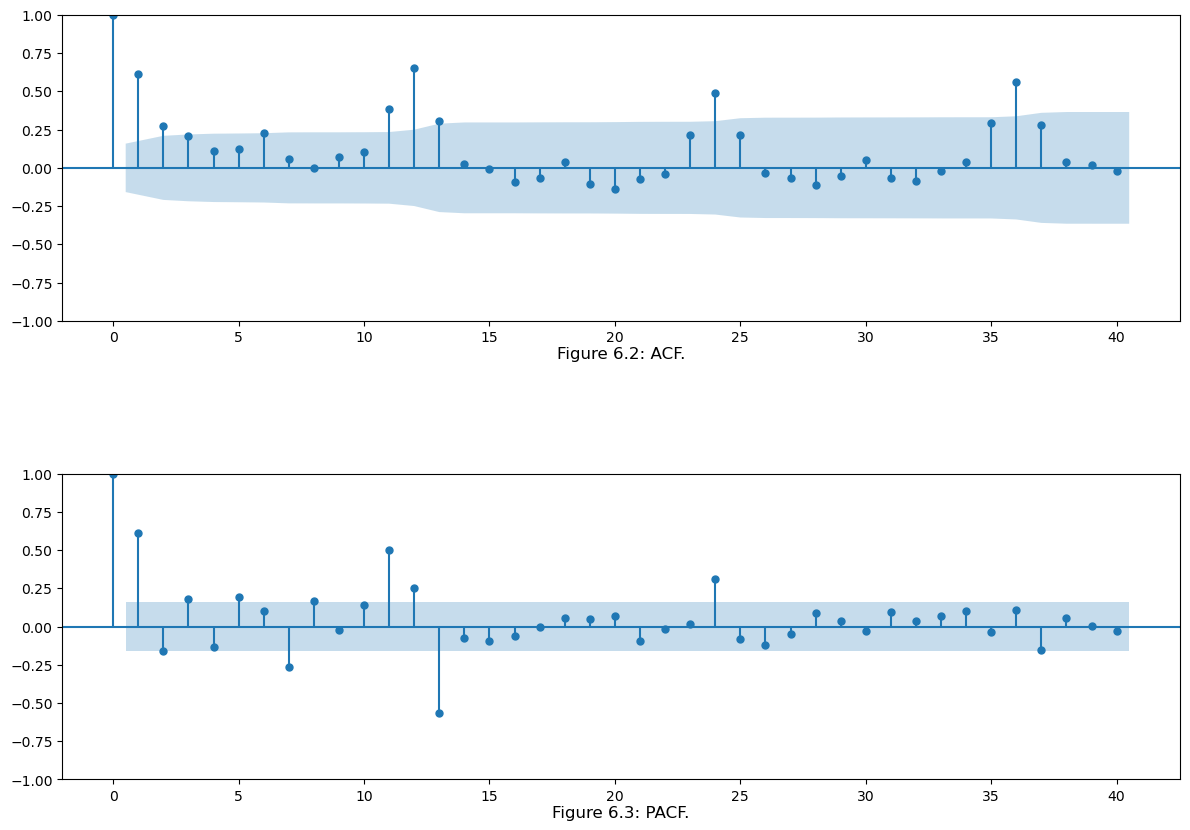

In [226]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(TimeSeries['Sales'], lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("Figure 6.2: ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(TimeSeries['Sales'], lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("Figure 6.3: PACF.",y=-0.15)

In [216]:
# SARIMA modelling
diff1 = TimeSeries['Sales'].diff().dropna()
print("ADF p-value after 1 diff:", adfuller(diff1)[1])

ADF p-value after 1 diff: 0.012174488835471765
ADF p-value after diff + seasonal diff: 0.0018864203722238143


Text(0.5, 1.0, 'First Order Difference')

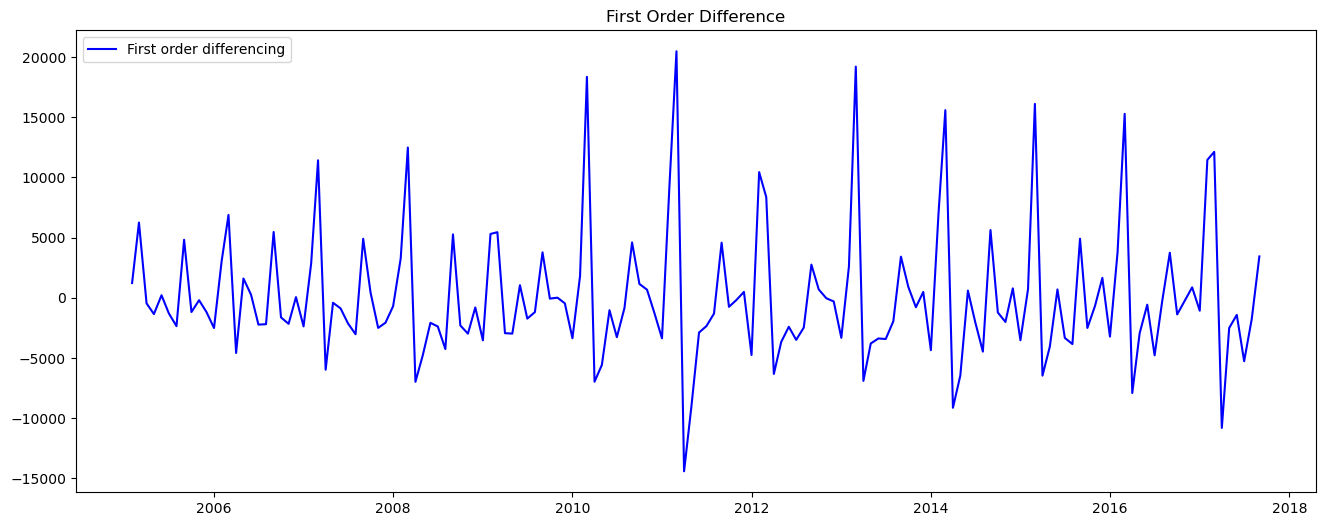

In [248]:
plt.figure(figsize=(16, 6))
plt.plot(diff1, label='First order differencing', color='blue')
plt.legend(loc='upper left')
plt.title('First Order Difference')

Text(0.5, -0.15, 'Figure 6.3: PACF.')

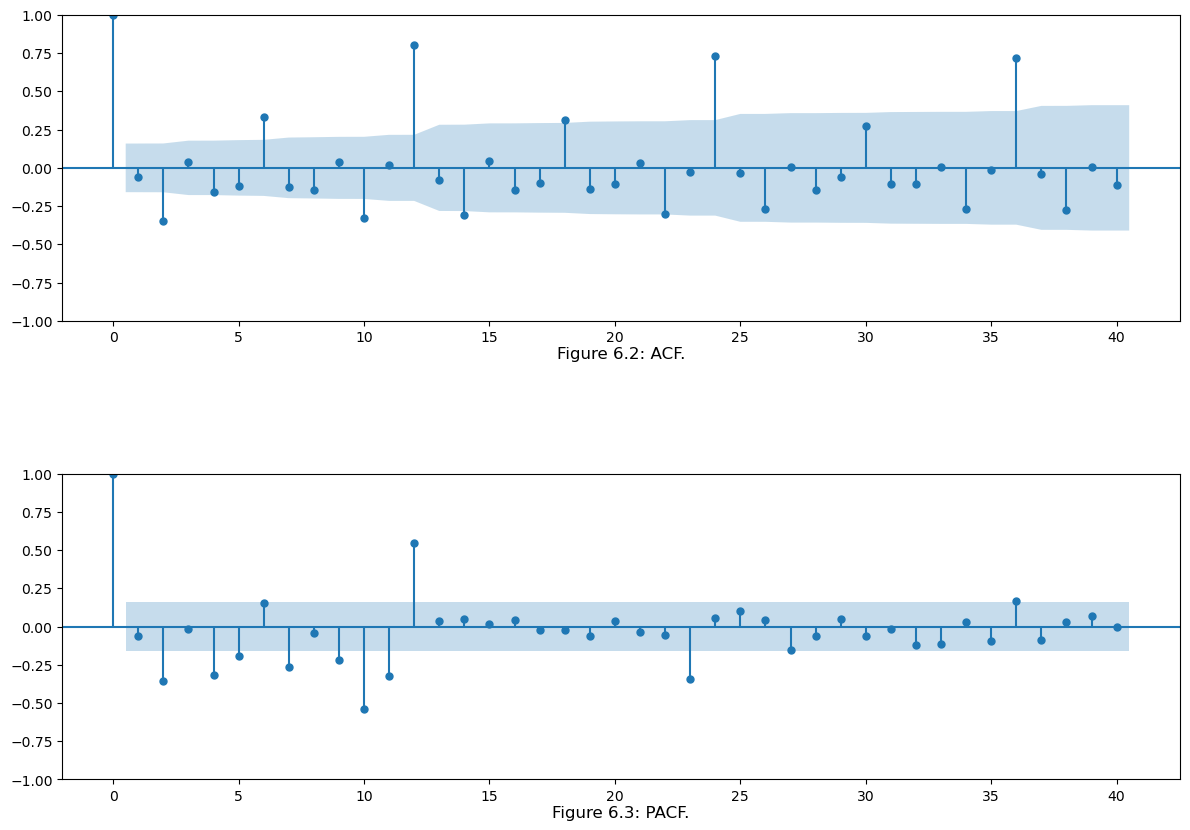

In [225]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(diff1, lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("Figure 6.2: ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(diff1, lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("Figure 6.3: PACF.",y=-0.15)	

In [252]:
combined_diff = TimeSeries['Sales'].diff().diff(12).dropna()
print("ADF p-value after diff + seasonal diff:", adfuller(combined_diff)[1])

ADF p-value after diff + seasonal diff: 0.0018864203722238143


Text(0.5, 1.0, 'First Order Difference and Seasonal Difference (12)')

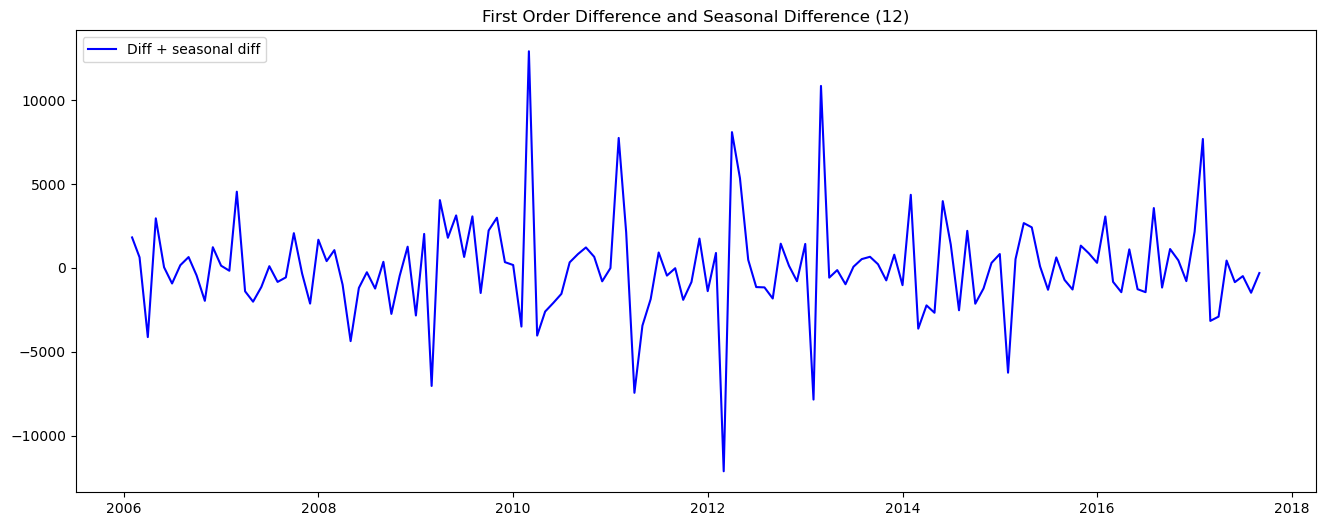

In [253]:
plt.figure(figsize=(16, 6))
plt.plot(combined_diff, label='Diff + seasonal diff', color='blue')
plt.legend(loc='upper left')
plt.title('First Order Difference and Seasonal Difference (12)')

Text(0.5, -0.15, 'PACF.')

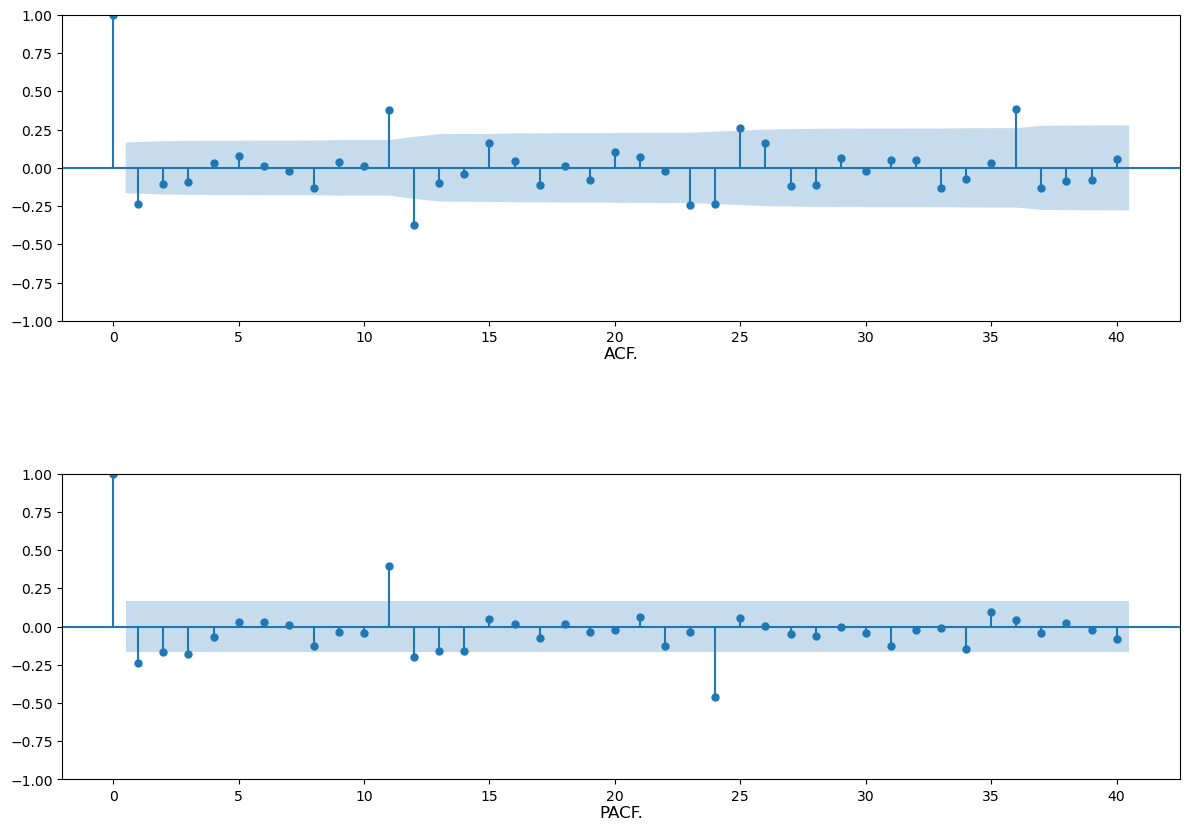

In [254]:
fig   = plt.figure(figsize=(12, 8))							                          #to create a new figure
ax1 = fig.add_subplot(211)								                                # to add a subplot
fig   = sm.graphics.tsa.plot_acf(combined_diff, lags=40, ax=ax1)		# to add ACF plot
ax1.set_title("ACF.",y=-0.15)			                  # to add a caption on to the plot

# Apply tight_layout and adjust
fig.tight_layout()
fig.subplots_adjust(wspace=1, hspace=0.5)                                 # Reduced hspace for better visibility

ax2 = fig.add_subplot(212)								                                # to add another subplot
fig  = sm.graphics.tsa.plot_pacf(combined_diff, lags=40, ax=ax2)				# to add a PACF plot
ax2.set_title("PACF.",y=-0.15)	

In [259]:
model_with_constant_V01 = ARIMA(combined_diff, order=(1, 0, 1)).fit()		  #to train an ARIMA(2,0,0) model
print(model_with_constant_V01.params)						                            #to show the coefficients of the ARIMA(2,0,0) model
sm.stats.acorr_ljungbox(model_with_constant_V01.resid, lags=[10], return_df=True)	  #to provide the Ljung-Box test
print(model_with_constant_V01.aic, model_with_constant_V01.bic)				                    #to provide the AIC and BIC of the model
print(model_with_constant_V01.summary())					                            #to output the summary of the ARMA model

#As can be seen from the above screenshot, the BIC becomes smaller, you can write up the following model
# x_t=0.0000646-0.8371x_{t-1}-0.2675x_{t-2}+e_t
#Note: $x_t$ is not the orginal time series as it has been transformed, differenced, and seasonal differenced

#From the above figure, we can see that the p-value for the constant is 0.979, which is larger than 0.05 and should therefore be removed. As such, we re-train an ARMA model.
model_without_constant_V01 = ARIMA(combined_diff, order=(1, 0, 1), trend='n').fit()		#to train an ARIMA(2,0,0) model and impose the constant item to be 0: 'n' for no constant
print(model_without_constant_V01.summary())

# Compare model performance
print("Model with constant AIC:", model_with_constant_V01.aic)
print("Model without constant AIC:", model_without_constant_V01.aic)

const     1.049310e+01
ar.L1     3.403296e-01
ma.L1    -6.630906e-01
sigma2    8.207151e+06
dtype: float64
2633.544836676878 2645.311406367315
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  140
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1312.772
Date:                Mon, 02 Mar 2026   AIC                           2633.545
Time:                        17:04:37   BIC                           2645.311
Sample:                    02-01-2006   HQIC                          2638.326
                         - 09-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4931    126.552      0.083      0.934    -237.545 

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [266]:
# Fit SARIMA with constant (drift)
model_with_constant = SARIMAX(
    TimeSeries['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    trend='n'   # include constant (drift)
).fit()

print(model_with_constant.params)
print(model_with_constant.aic, model_with_constant.bic)
print(model_with_constant.summary())

# Ljung-Box test
sm.stats.acorr_ljungbox(model_with_constant.resid, lags=[10], return_df=True)

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ar.L1       3.851199e-01
ma.L1      -6.687106e-01
ar.S.L12    4.175860e-02
ma.S.L12   -5.676760e-01
sigma2      6.369735e+06
dtype: float64
2603.5939287359324 2618.302140848979
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  153
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1296.797
Date:                            Mon, 02 Mar 2026   AIC                           2603.594
Time:                                    17:58:45   BIC                           2618.302
Sample:                                01-01-2005   HQIC                          2609.571
                                     - 09-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------

,lb_stat,lb_pvalue
10,5.779934,0.833401


In [268]:
# Fit SARIMA with constant (drift)
model_with_constant = SARIMAX(
    TimeSeries['Sales'],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    trend='n'   # include constant (drift)
).fit()

print(model_with_constant.params)
print(model_with_constant.aic, model_with_constant.bic)
print(model_with_constant.summary())

# Ljung-Box test
sm.stats.acorr_ljungbox(model_with_constant.resid, lags=[10], return_df=True)

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ar.L1       3.850657e-01
ma.L1      -6.674077e-01
ma.S.L12   -5.394803e-01
sigma2      6.377314e+06
dtype: float64
2601.6884960107554 2613.455065701193
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  153
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1296.844
Date:                            Mon, 02 Mar 2026   AIC                           2601.688
Time:                                    18:00:41   BIC                           2613.455
Sample:                                01-01-2005   HQIC                          2606.470
                                     - 09-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

,lb_stat,lb_pvalue
10,5.884963,0.824834


In [269]:
residuals = model_with_constant.resid

# -----------------------------
# 3. Prepare regressors for White test
# White test requires exogenous variables.
# For ARMA residuals, we typically regress on fitted values.
# -----------------------------
fitted_vals = model_with_constant.fittedvalues

# Add constant term
X = sm.add_constant(fitted_vals)

# -----------------------------
# 4. Perform White test
# -----------------------------
white_test = het_white(residuals, X)

lm_stat = white_test[0]
lm_pvalue = white_test[1]
white_statistic = white_test[2]
white_pvalue = white_test[3]

print("White Test Results")
print("------------------")
print(f"LM Statistic: {lm_stat}")
print(f"LM p-value: {lm_pvalue}")
print(f"F-Statistic: {white_statistic}")
print(f"F p-value: {white_pvalue}")


print("Whites Test Statistic:", white_statistic)
print(f"P-value: {white_pvalue:.4f}")

# Interpretation
alpha = 0.05
if white_pvalue > alpha:
    print("Conclusion: Residuals appear homoskedastic (or homogeneitic) (fail to reject H0)") #that is, constant variance
else:
    print("Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)") #that is, inconstant variance

White Test Results
------------------
LM Statistic: 15.382108495480297
LM p-value: 0.0004568962359156285
F-Statistic: 8.383053428217462
F p-value: 0.0003538018965403461
Whites Test Statistic: 8.383053428217462
P-value: 0.0004
Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)


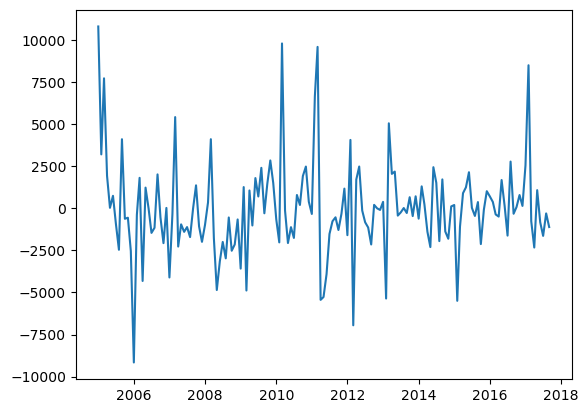

In [270]:
plt.plot(residuals)

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


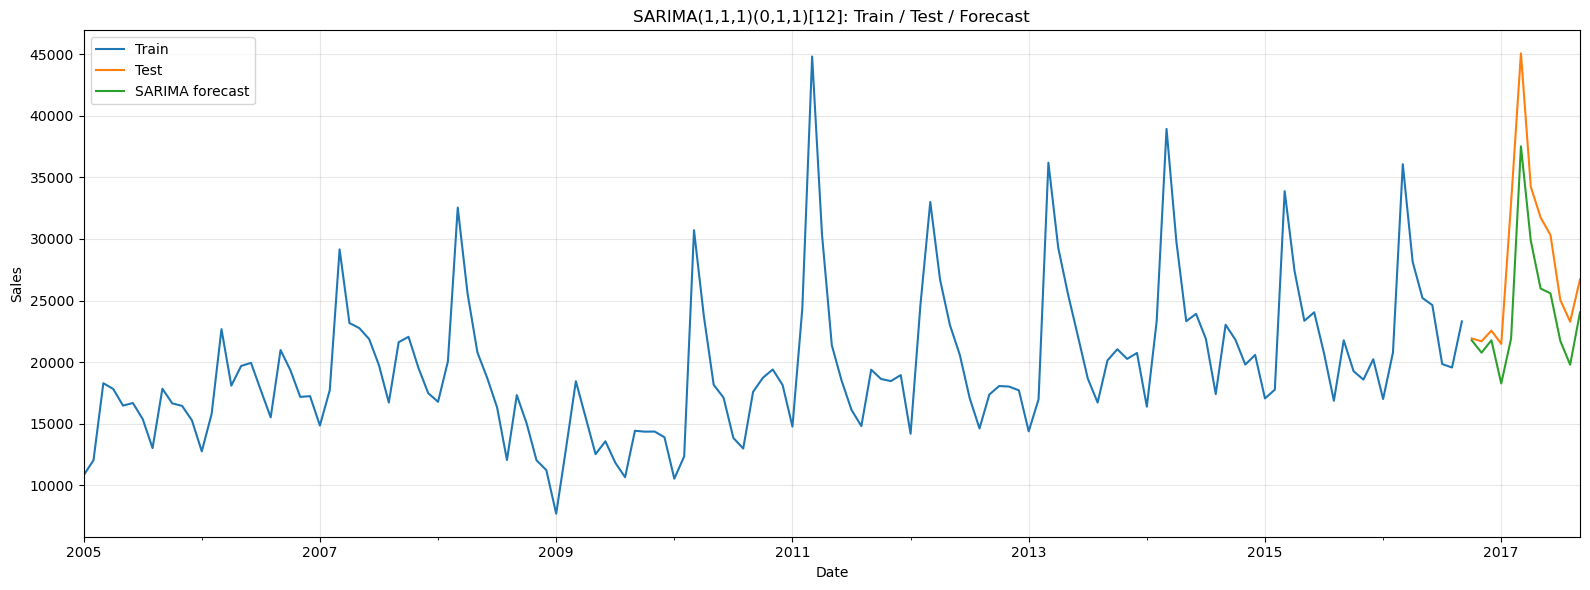

Mean Absolute Error (SARIMA) = 3998.62
SARIMA AIC = 2381.72
SARIMA BIC = 2393.12


In [274]:
# ----------------------------
# Fit SARIMA on training data
# ----------------------------
sarima_model = SARIMAX(
    train_TimeSeries["Sales"],
    order=(1,1,1),
    seasonal_order=(0,1,1,12),
    trend='n'   # no constant (based on earlier result)
).fit()

# ----------------------------
# Forecast test horizon
# ----------------------------
n_forecast = len(test_TimeSeries)

sarima_forecast = sarima_model.get_forecast(steps=n_forecast)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

# ----------------------------
# Plot results
# ----------------------------
fig, ax = plt.subplots(figsize=(16, 6))

train_TimeSeries["Sales"].plot(ax=ax, label="Train")
test_TimeSeries["Sales"].plot(ax=ax, label="Test")
sarima_pred.plot(ax=ax, label="SARIMA forecast")

# Confidence intervals

ax.set_title("SARIMA(1,1,1)(0,1,1)[12]: Train / Test / Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------
# Evaluation
# ----------------------------
mae_sarima = mean_absolute_error(test_TimeSeries["Sales"], sarima_pred)

print(f"Mean Absolute Error (SARIMA) = {mae_sarima:.2f}")
print(f"SARIMA AIC = {sarima_model.aic:.2f}")
print(f"SARIMA BIC = {sarima_model.bic:.2f}")

In [275]:
model_comparison = pd.DataFrame({
    "Model": ["Holt-Winters", "SARIMA(1,1,1)(0,1,1)[12]"],
    "AIC": [HW_model.aic, sarima_model.aic],
    "BIC": [HW_model.bic, sarima_model.bic],
    "MAE (Test Set)": [mae, mae_sarima]
})

In [276]:
model_comparison

,Model,AIC,BIC,MAE (Test Set)
0,Holt-Winters,2175.495851,2222.676009,2894.979431
1,"SARIMA(1,1,1)(0,1,1)[12]",2381.716355,2393.124476,3998.616754


## 3) Linear regression
Download dataset Regression_Dataset.csv. Develop a linear regression model with variable credit_score as the dependent variable and the other variables as independent variables (you may select some of them), where “job_type1=1” represents “freelance”, “job_type2=1” represents “fixed”. Provide your modelling process and final model. 

In [3]:
Regression_Dataset = pd.read_csv("Datasets/Regression_Dataset.csv")

In [4]:
Regression_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4420 entries, 0 to 4419
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Customer ID   4420 non-null   int64 
 1   Marital       4420 non-null   object
 2   Job           4420 non-null   object
 3   Home          4420 non-null   object
 4   Income        4420 non-null   int64 
 5   Expenses      4420 non-null   int64 
 6   Assets        4420 non-null   int64 
 7   Debt          4420 non-null   int64 
 8   Loan_Term     4420 non-null   int64 
 9   Loan_Amount   4420 non-null   int64 
 10  Job_type_1    4420 non-null   int64 
 11  Job_type_2    4420 non-null   int64 
 12  Credit Score  4420 non-null   int64 
dtypes: int64(10), object(3)
memory usage: 449.0+ KB


In [5]:
Regression_Dataset.head()

,Customer ID,Marital,Job,Home,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Job_type_1,Job_type_2,Credit Score
0,364782,married,freelance,tenant,129000,73000,0,0,60,800,1,0,54
1,364783,single,fixed,tenant,131000,48000,0,0,60,1000,0,1,65
2,364784,married,freelance,owner,200000,90000,3000,0,36,2000,1,0,49
3,364785,single,fixed,tenant,182000,63000,2500,0,60,900,0,1,55
4,364786,single,fixed,tenant,107000,46000,0,0,36,310,0,1,75


In [6]:
# One-hot encode with n-1 dummies per column
df_encoded = pd.get_dummies(Regression_Dataset, columns=['Marital', 'Job', 'Home'], drop_first=True, dtype=int)

In [7]:
(df_encoded['Job_freelance'] == df_encoded['Job_type_1']).all()

np.True_

In [8]:
df_regress = df_encoded.drop(columns=["Job_type_1", "Job_type_2", "Customer ID"])

In [9]:
df_regress

,Income,Expenses,Assets,Debt,Loan_Term,Loan_Amount,Credit Score,Marital_single,Job_freelance,Job_parttime,Home_tenant
0,129000,73000,0,0,60,800,54,0,1,0,1
1,131000,48000,0,0,60,1000,65,1,0,0,1
2,200000,90000,3000,0,36,2000,49,0,1,0,0
3,182000,63000,2500,0,60,900,55,1,0,0,1
4,107000,46000,0,0,36,310,75,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4415,100000,35000,5000,0,60,900,73,0,0,0,0
4416,140000,45000,4300,0,60,2200,57,0,1,0,0
4417,154000,35000,7000,1700,36,1400,78,0,0,0,0
4418,150000,60000,9000,0,60,1300,71,0,0,0,0


In [10]:
X = df_regress.drop(columns = ["Credit Score"])
y = df_regress["Credit Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
predictors = X_train

In [12]:
# to define a VIF dataframe
vif_data = pd.DataFrame()

#to remind ourselves that the independent feature part defined in Q3 are X_FFSM

vif_data["feature"] = predictors.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(predictors.values, i)
                          for i in range(len(predictors.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)
# Drop the constant

print(vif_data)

# Interpretation
print("\n VIF Interpretation:")
print(" VIF = 1: No correlation")
print(" 1 < VIF < 5: Moderate correlation (usually acceptable)")
print(" 5 ≤ VIF < 10: High correlation (potential problem)")
print(" VIF ≥ 10: Serious multicollinearity")

          feature        VIF
4       Loan_Term  10.246677
1        Expenses   8.282551
5     Loan_Amount   7.499913
0          Income   4.599324
9     Home_tenant   2.604205
6  Marital_single   1.749393
7   Job_freelance   1.499934
2          Assets   1.440488
8    Job_parttime   1.183903
3            Debt   1.152402

 VIF Interpretation:
 VIF = 1: No correlation
 1 < VIF < 5: Moderate correlation (usually acceptable)
 5 ≤ VIF < 10: High correlation (potential problem)
 VIF ≥ 10: Serious multicollinearity


In [13]:
predictors2 = X_train.drop(columns = ["Loan_Term"])

In [14]:
# to define a VIF dataframe
vif_data = pd.DataFrame()

#to remind ourselves that the independent feature part defined in Q3 are X_FFSM

vif_data["feature"] = predictors2.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(predictors2.values, i)
                          for i in range(len(predictors2.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)
# Drop the constant

print(vif_data)

# Interpretation
print("\n VIF Interpretation:")
print(" VIF = 1: No correlation")
print(" 1 < VIF < 5: Moderate correlation (usually acceptable)")
print(" 5 ≤ VIF < 10: High correlation (potential problem)")
print(" VIF ≥ 10: Serious multicollinearity")

          feature       VIF
1        Expenses  6.463700
4     Loan_Amount  4.903069
0          Income  4.599321
8     Home_tenant  2.586679
5  Marital_single  1.655009
6   Job_freelance  1.484896
2          Assets  1.432996
7    Job_parttime  1.181643
3            Debt  1.143283

 VIF Interpretation:
 VIF = 1: No correlation
 1 < VIF < 5: Moderate correlation (usually acceptable)
 5 ≤ VIF < 10: High correlation (potential problem)
 VIF ≥ 10: Serious multicollinearity


In [15]:
predictors3 = X_train.drop(columns = ["Loan_Term", "Expenses"])

In [16]:
# to define a VIF dataframe
vif_data = pd.DataFrame()

#to remind ourselves that the independent feature part defined in Q3 are X_FFSM

vif_data["feature"] = predictors3.columns

# to calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(predictors3.values, i)
                          for i in range(len(predictors3.columns))]

vif_data = vif_data.sort_values('VIF', ascending=False)
# Drop the constant

print(vif_data)

# Interpretation
print("\n VIF Interpretation:")
print(" VIF = 1: No correlation")
print(" 1 < VIF < 5: Moderate correlation (usually acceptable)")
print(" 5 ≤ VIF < 10: High correlation (potential problem)")
print(" VIF ≥ 10: Serious multicollinearity")

          feature       VIF
3     Loan_Amount  3.922243
0          Income  3.443444
7     Home_tenant  2.288429
4  Marital_single  1.524110
5   Job_freelance  1.446853
1          Assets  1.432352
6    Job_parttime  1.166599
2            Debt  1.142290

 VIF Interpretation:
 VIF = 1: No correlation
 1 < VIF < 5: Moderate correlation (usually acceptable)
 5 ≤ VIF < 10: High correlation (potential problem)
 VIF ≥ 10: Serious multicollinearity


In [17]:
vif_data

,feature,VIF
3,Loan_Amount,3.922243
0,Income,3.443444
7,Home_tenant,2.288429
4,Marital_single,1.524110
5,Job_freelance,1.446853
1,Assets,1.432352
6,Job_parttime,1.166599
2,Debt,1.142290


In [18]:
#########below is a function that implements the forward feature selection method########
def forward_regression(X, y, #the features and the target
                       initial_list=[], # initial list containing no features
                       threshold_in=0.01, #the threshold determining a feature should be included
                       verbose=True): #True: you would like to print "Drop with p-value"
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            # Change argmin -> idxmin
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add with p-value '.format(best_feature, best_pval))

        if not changed:
            break

    return included

#########end of the forward feature selection method########


#########below is a function that implements the backward feature selection method########
def backward_regression(X, y, # the target and the features
                           threshold_out = 0.05, #the threshold determining a feature should be excluded
                           verbose=True): #True: you would like to print "Drop with p-value"
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop with p-value '.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [19]:
Selected_Features=backward_regression(X_train, y_train) #Selected_Features is a list of selected features based on the backward feature selection method

X_BFSM = X_train[Selected_Features] #select the instances of the list of selected features

#to add constant to predictor features
X_BFSM = sm.add_constant(X_BFSM)

#to fit regression model
model_BFSM = sm.OLS(y_train, X_BFSM).fit()# the model built based on the backward feature selection method (BFSM)

#to view model summary
print(model_BFSM.summary())

                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     409.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:50:53   Log-Likelihood:                -13513.
No. Observations:                3536   AIC:                         2.705e+04
Df Residuals:                    3525   BIC:                         2.712e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             86.8987      1.001     86.

In [20]:
Selected_Features=forward_regression(X_train, y_train) #Selected_Features is a list of selected features based on the backward feature selection method

X_FFSM = X_train[Selected_Features] #select the instances of the list of selected features

#to add constant to predictor features
X_FFSM = sm.add_constant(X_FFSM)

#to fit regression model
model_FFSM = sm.OLS(y_train, X_FFSM).fit()# the model built based on the backward feature selection method (BFSM)

#to view model summary
print(model_FFSM.summary())

Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     409.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:50:53   Log-Likelihood:                -13513.
No. Observations:                3536   AIC:                         2.705e+04
Df Residuals:                    3525   BIC:                         2.712e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    s

In [53]:
print(model_no_out.summary())

                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     444.2
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:27:30   Log-Likelihood:                -12637.
No. Observations:                3378   AIC:                         2.530e+04
Df Residuals:                    3367   BIC:                         2.536e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             86.5054      0.964     89.

Text(0, 0.5, 'standardised Residuals')

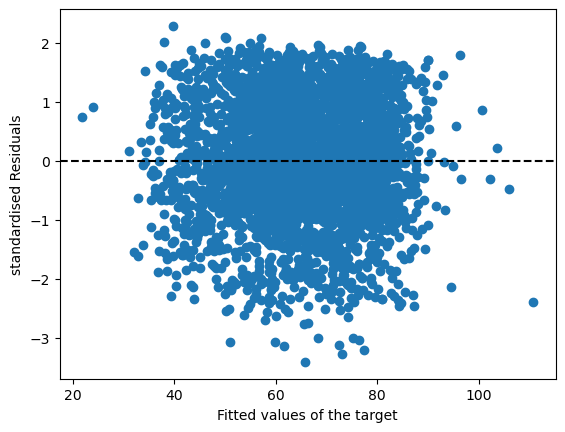

In [21]:
# Get standardised residuals
standardised_residuals = model_FFSM.get_influence().resid_studentized_internal

# Defining feature values and
# standardised residuals
x1 = model_FFSM.fittedvalues
y1 = standardised_residuals

# Creating a scatterplot of fitted predictor feature
# vs standardised residuals
plt.scatter(x1, y1)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Fitted values of the target')
plt.ylabel('standardised Residuals')

In [22]:
#perform White's test
white_test = het_white(model_FFSM.resid, model_FFSM.model.exog)

# Extract results
white_statistic = white_test[0]
white_pvalue = white_test[1]
f_statistic = white_test[2]
f_pvalue = white_test[3]

print("Whites Test Statistic:", white_statistic)
print(f"P-value: {white_pvalue:.4f}")

# Interpretation
alpha = 0.05
if white_pvalue > alpha:
    print("Conclusion: Residuals appear homoskedastic (or homogeneitic) (fail to reject H0)") #that is, constant variance
else:
    print("Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)") #that is, inconstant variance

Whites Test Statistic: 159.3710767315945
P-value: 0.0000
Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)


Jarque-Bera Statistic: 61.5577
P-value: 0.0000
Skewness: -0.2409
Kurtosis: 2.5691
Conclusion: Residuals are NOT normally distributed (reject H0)


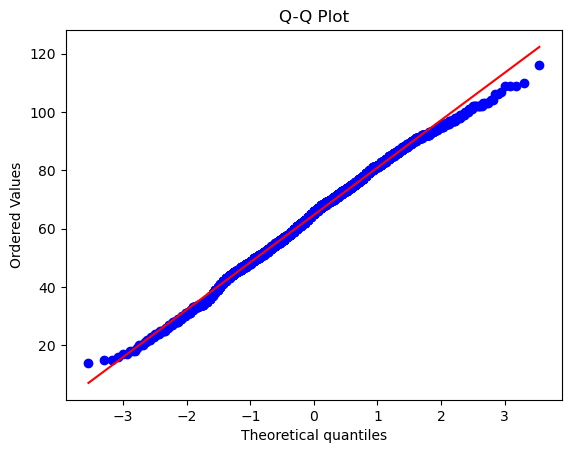

In [36]:
# Calculate Jarque-Bera test
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(model_FFSM.resid)

print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"P-value: {jb_pvalue:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Interpretation
alpha = 0.05
if jb_pvalue > alpha:
    print("Conclusion: Residuals appear normally distributed (fail to reject H0)")
else:
    print("Conclusion: Residuals are NOT normally distributed (reject H0)")

fig, ax1 = plt.subplots()


# Q-Q plot
#suppose you want to create a QQ plot to check with the target y is normally distributed
stats.probplot(y_train, dist="norm", plot=plt)
ax1.set_title('Q-Q Plot')
plt.show()

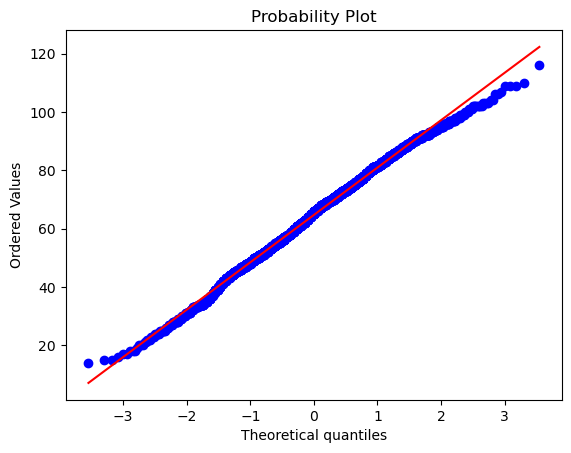

In [54]:
# Q-Q plot
#suppose you want to create a QQ plot to check with the target y is normally distributed
stats.probplot(y_train, dist="norm", plot=plt)
ax1.set_title('Q-Q Plot')
plt.show()

Lambda: 1.1551594437945263
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     409.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:44:37   Log-Likelihood:                -15777.
No. Observations:                3536   AIC:                         3.158e+04
Df Residuals:                    3525   BIC:                         3.164e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            

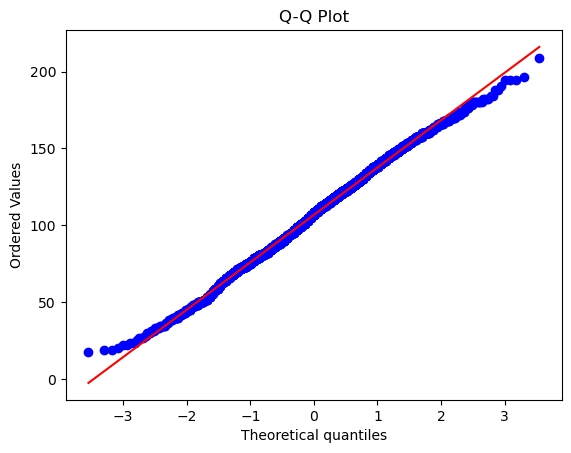

Whites Test Statistic: 163.24551101310675
P-value: 0.0000
Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)


In [41]:
z, lam = stats.boxcox(y_train)
print("Lambda:", lam)

#to refit a linear regression model, the dependent variable is z
newModel = sm.OLS(z, X_FFSM).fit()

#if you want to make prediction
predictions = newModel.predict(X_FFSM)

#to view model summary
print(newModel.summary())

residuals = newModel.resid

####
# Calculate Jarque-Bera test
jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"P-value: {jb_pvalue:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Interpretation
alpha = 0.05
if jb_pvalue > alpha:
    print("Conclusion: Residuals appear normally distributed (fail to reject H0)")
else:
    print("Conclusion: Residuals are NOT normally distributed (reject H0)")

fig, ax1 = plt.subplots()

# Q-Q plot
#suppose you want to create a QQ plot to check with the target y is normally distributed
stats.probplot(z, dist="norm", plot=plt)
ax1.set_title('Q-Q Plot')
plt.show()

#perform White's test
white_test = het_white(newModel.resid, newModel.model.exog)

# Extract results
white_statistic = white_test[0]
white_pvalue = white_test[1]
f_statistic = white_test[2]
f_pvalue = white_test[3]

print("Whites Test Statistic:", white_statistic)
print(f"P-value: {white_pvalue:.4f}")

# Interpretation
alpha = 0.05
if white_pvalue > alpha:
    print("Conclusion: Residuals appear homoskedastic (or homogeneitic) (fail to reject H0)") #that is, constant variance
else:
    print("Conclusion: Residuals appear heteroskedastic (or heterogeneitic)  (reject H0)") #that is, inconstant variance

Threshold for Cook Distance = 0.0011312217194570137
Proportion of data points that are highly influential = 4.5%
Proportion of data points that are highly influential and outliers = 0.2%
       cooks_d  std_resid
4076  0.014579   3.258591
243   0.006523   3.069998
2373  0.004693   3.139859
3449  0.003573   3.062999
4012  0.003131   3.408858
2067  0.002834   3.031004
4122  0.002830   3.201256
4265  0.002653   3.006957
742   0.002400   3.120344


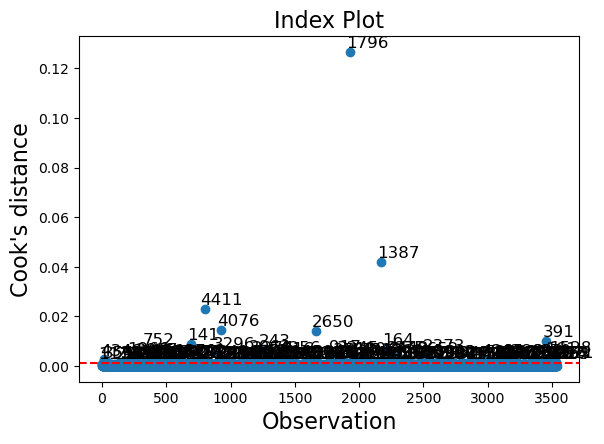

In [50]:
######################################
#####to calculate Cook's distance#####
######################################

from scipy import stats

# Get influence measures: to iniliaze
influence = model_FFSM.get_influence()

# Obtain summary df of influence measures
summ_df = influence.summary_frame()

# Filter summary df to Cook distance
diagnosis_df = summ_df.loc[:,['cooks_d']]

# Append absolute standardized residual values
diagnosis_df['std_resid'] = stats.zscore(model_FFSM.resid_pearson)
diagnosis_df['std_resid'] = diagnosis_df.loc[:,'std_resid'].apply(lambda x: np.abs(x))

# Sort by Cook's Distance
diagnosis_df.sort_values("cooks_d", ascending=False)
diagnosis_df.head()

# Set Cook's distance threshold
cook_threshold = 4 / len(X_train)
print(f"Threshold for Cook Distance = {cook_threshold}")

import matplotlib.pyplot as plt
# Plot influence measures (Cook's distance)
fig = influence.plot_index(y_var="cooks", threshold=cook_threshold)
plt.axhline(y = cook_threshold, ls="--", color='red')
fig.tight_layout(pad=2) #those instances above the read line are influential instances.

# Find number of observations that exceed Cook's distance threshold
influentials = diagnosis_df[diagnosis_df['cooks_d'] > cook_threshold]
prop_influentials = round(100*(len(influentials) / len(X_train)),1)
print(f'Proportion of data points that are highly influential = {prop_influentials}%')


# Find number of observations which are BOTH outlier (std dev > 3) and highly influential
extreme = diagnosis_df[(diagnosis_df['cooks_d'] > cook_threshold) &
                       (diagnosis_df['std_resid'] > 3)]
prop_extreme = round(100*(len(extreme) / len(X)),1)
print(f'Proportion of data points that are highly influential and outliers = {prop_extreme}%')

# Display top 5 most influential instances and outliers
print(extreme.sort_values("cooks_d", ascending=False))


In [51]:
X_no_out = X_FFSM.drop(influentials.index)
y_no_out = y_train.drop(influentials.index)

model_no_out = sm.OLS(y_no_out, X_no_out).fit()

#to view model summary
print(model_no_out.summary())

                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     444.2
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:24:08   Log-Likelihood:                -12637.
No. Observations:                3378   AIC:                         2.530e+04
Df Residuals:                    3367   BIC:                         2.536e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             86.5054      0.964     89.

In [56]:
# -----------------------------
# Helper: align test features to each fitted statsmodels OLS model
# -----------------------------
def build_test_matrix_for_model(model, X_test):
    """
    Returns an exogenous test matrix with the exact columns/order
    expected by a fitted statsmodels model.
    """
    exog_names = model.model.exog_names[:]   # includes 'const' if present

    X_model = X_test.copy()

    # Add constant if model expects it
    if 'const' in exog_names and 'const' not in X_model.columns:
        X_model = sm.add_constant(X_model, has_constant='add')

    # Keep only columns used by the model, in the correct order
    X_model = X_model.reindex(columns=exog_names)

    # Safety check for missing columns
    missing_cols = X_model.columns[X_model.isnull().all()].tolist()
    if missing_cols:
        raise ValueError(
            f"These columns required by the model are missing from X_test: {missing_cols}"
        )

    return X_model


# -----------------------------
# Helper: evaluate a fitted model on test data
# -----------------------------
def evaluate_model(model, X_test, y_test, model_name):
    X_eval = build_test_matrix_for_model(model, X_test)
    y_pred = model.predict(X_eval)

    # Residuals
    residuals = y_test - y_pred

    # Number of predictors excluding intercept
    k = sum(col != 'const' for col in model.model.exog_names)

    # Sample size
    n = len(y_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    med_ae = median_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Adjusted R^2 on the test set
    adj_r2 = np.nan
    if n > k + 1:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    # MAPE can break if y_test contains zeros
    if np.any(np.array(y_test) == 0):
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(y_test, y_pred)

    # Information on model structure
    features_used = [col for col in model.model.exog_names if col != 'const']

    return {
        "Model": model_name,
        "Num_features": k,
        "Features_used": ", ".join(features_used),
        "Test_R2": r2,
        "Test_Adjusted_R2": adj_r2,
        "Test_RMSE": rmse,
        "Test_MSE": mean_squared_error(y_test, y_pred),
        "Test_MAE": mae,
        "Test_Median_AE": med_ae,
        "Test_MAPE": mape,
        "Mean_Residual": np.mean(residuals),
        "Residual_SD": np.std(residuals, ddof=1)
    }


# -----------------------------
# Compare both models on X_test / y_test
# -----------------------------
results = pd.DataFrame([
    evaluate_model(model_FFSM, X_test, y_test, "model_FFSM"),
    evaluate_model(model_no_out, X_test, y_test, "model_no_out")
])

# Optional: sort columns for readability
results = results[
    [
        "Model",
        "Num_features",
        "Features_used",
        "Test_R2",
        "Test_Adjusted_R2",
        "Test_RMSE",
        "Test_MSE",
        "Test_MAE",
        "Test_Median_AE",
        "Test_MAPE",
        "Mean_Residual",
        "Residual_SD"
    ]
]

# Round numeric columns
numeric_cols = results.select_dtypes(include=np.number).columns
results[numeric_cols] = results[numeric_cols].round(4)

print(results)

          Model  Num_features  \
0    model_FFSM            10   
1  model_no_out            10   

                                       Features_used  Test_R2  \
0  Home_tenant, Job_parttime, Loan_Amount, Income...   0.5135   
1  Home_tenant, Job_parttime, Loan_Amount, Income...   0.5067   

   Test_Adjusted_R2  Test_RMSE  Test_MSE  Test_MAE  Test_Median_AE  Test_MAPE  \
0             0.508    11.1931  125.2849    9.1625          8.3664     0.1653   
1             0.501    11.2717  127.0501    9.1920          8.5838     0.1674   

   Mean_Residual  Residual_SD  
0        -0.8404      11.1678  
1        -1.4384      11.1858  


In [57]:
results

,Model,Num_features,Features_used,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MSE,Test_MAE,Test_Median_AE,Test_MAPE,Mean_Residual,Residual_SD
0,model_FFSM,10,"Home_tenant, Job_parttime, Loan_Amount, Income...",0.5135,0.508,11.1931,125.2849,9.1625,8.3664,0.1653,-0.8404,11.1678
1,model_no_out,10,"Home_tenant, Job_parttime, Loan_Amount, Income...",0.5067,0.501,11.2717,127.0501,9.1920,8.5838,0.1674,-1.4384,11.1858


In [59]:
print(model_FFSM.summary())

                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     409.9
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:48:54   Log-Likelihood:                -13513.
No. Observations:                3536   AIC:                         2.705e+04
Df Residuals:                    3525   BIC:                         2.712e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             86.8987      1.001     86.